In [1]:
# import importlib
# from src.utils import statistics

# importlib.reload(statistics)

# from src.utils.statistics import hierarchical_impute

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.style import set_plot_style, COLORS, fa
from src.utils.plot_utils import save_figure
from src.utils.statistics import normalize_year, normalize_integer, missing_by_group, hierarchical_impute

set_plot_style()

In [3]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

In [4]:
df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df[df["cat2_slug"] == "real-estate-services"].head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
125,125,real-estate-services,presell,karaj,malard,2024-07-01 00:00:00,NaN,۸۰ متر نوساز کلید نخورده\n✅دوخواب\n✅روب نما\n✅...,۸۰ متر نو سازخیابان سعدی/ملارد/سراسیاب/املاک م...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.670135,50.978745,500.0
127,127,real-estate-services,presell,eslamshahr,NaN,2024-10-01 00:00:00,NaN,پیش فروش آپارتمان✅\n\nمحدوده: واوان✓هشت بهشت✅\...,64متری پیش فروش واوان,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.496750,51.224159,NaN
203,203,real-estate-services,partnership,pakdasht-city,NaN,2024-12-01 00:00:00,NaN,۲۱۰ متر با بر ۱۰\nیبر\n۱۹۰ متر پیشروی\nدرصد ۶۰...,۲۱۰/متر/مشارکت,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.475899,51.695000,NaN
243,243,real-estate-services,presell,mashhad,elahiyehblvd,2024-05-01 00:00:00,مشاور املاک,سلام احترام \nواحد ۸۵ متری سر جلو \nآفتابگیر \...,۸۵ متر الهیه پیش فروش,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435,435,real-estate-services,presell,shiraz,farhangian-shiraz,2024-09-01 00:00:00,NaN,پیش فروش آپارتمان دو خوابه فاز ۱ سند ملکی\nموق...,فروش آپارتمان دو خوابه فاز ۱ صدرا,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(1000000, 61)

In [7]:
df.columns

Index(['Unnamed: 0', 'cat2_slug', 'cat3_slug', 'city_slug',
       'neighborhood_slug', 'created_at_month', 'user_type', 'description',
       'title', 'rent_mode', 'rent_value', 'rent_to_single', 'rent_type',
       'price_mode', 'price_value', 'credit_mode', 'credit_value',
       'rent_credit_transform', 'transformable_price', 'transformable_credit',
       'transformed_credit', 'transformable_rent', 'transformed_rent',
       'land_size', 'building_size', 'deed_type', 'has_business_deed', 'floor',
       'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony',
       'has_elevator', 'has_warehouse', 'has_parking', 'construction_year',
       'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity',
       'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity',

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

In [9]:
df.isnull().sum()

Unnamed: 0                         0
cat2_slug                          0
cat3_slug                          1
city_slug                          2
neighborhood_slug             562861
                               ...  
rent_price_on_special_days    989537
rent_price_at_weekends        986449
location_latitude             344392
location_longitude            344392
location_radius               660301
Length: 61, dtype: int64

In [10]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool

In [11]:
# rooms_count
df_rooms_count = df.copy()

In [12]:
df_rooms_count["rooms_count"].value_counts()

rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [13]:
df_rooms_count["rooms_count"] = pd.Categorical(
    df_rooms_count["rooms_count"],
    categories=["بدون اتاق", "یک", "دو", "سه", "چهار", "پنج یا بیشتر"],
    ordered=True,
)

In [14]:
mapping = {"بدون اتاق": 0, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج یا بیشتر": 5}

df_rooms_count["rooms_count"] = df_rooms_count["rooms_count"].map(mapping).astype("Int8")

In [15]:
df_rooms_count["rooms_count"].value_counts()

rooms_count
2    404050
1    192083
3    138633
0     75898
4     21371
5     13864
Name: count, dtype: Int64

In [16]:
df = df_rooms_count

In [17]:
# construction_year
df_construction_year = df.copy()

In [18]:
df_construction_year["construction_year"].value_counts()

construction_year
۱۴۰۳           116260
۱۳۹۰            59139
۱۴۰۲            58424
۱۴۰۰            53674
۱۳۹۵            53029
۱۳۹۸            38207
۱۳۹۷            36326
۱۳۹۶            35487
۱۴۰۱            35328
۱۳۸۵            34065
۱۳۹۹            29594
۱۳۹۳            29094
۱۳۹۲            26130
۱۳۹۴            26110
۱۳۸۸            24268
۱۳۸۰            23480
قبل از ۱۳۷۰     20637
۱۳۸۹            16755
۱۳۹۱            16316
۱۳۸۷            14136
۱۳۸۶            13468
۱۳۸۳             9894
۱۳۸۴             8494
۱۳۷۵             7247
۱۳۸۲             6965
۱۳۷۱             5531
۱۳۸۱             3590
۱۳۷۸             3025
۱۳۷۹             2415
۱۳۷۷             2117
۱۳۷۲             1914
۱۳۷۳             1827
۱۳۷۶             1593
۱۳۷۴             1289
Name: count, dtype: int64

In [19]:
df_construction_year["construction_year"] = (
    df_construction_year["construction_year"].apply(normalize_year).astype("Int16")
)

In [20]:
df_construction_year["construction_year"].value_counts()

construction_year
1403    116260
1390     59139
1402     58424
1400     53674
1395     53029
1398     38207
1397     36326
1396     35487
1401     35328
1385     34065
1399     29594
1393     29094
1392     26130
1394     26110
1388     24268
1380     23480
1370     20637
1389     16755
1391     16316
1387     14136
1386     13468
1383      9894
1384      8494
1375      7247
1382      6965
1371      5531
1381      3590
1378      3025
1379      2415
1377      2117
1372      1914
1373      1827
1376      1593
1374      1289
Name: count, dtype: Int64

In [21]:
df = df_construction_year

In [22]:
# total_floors_count
df_total_floors_count = df.copy()

In [23]:
df_total_floors_count["total_floors_count"].value_counts(dropna=False)

total_floors_count
NaN         695648
4            89526
5            79911
3            52752
6            28877
2            22733
7             8271
8             4585
14            3046
10            2914
9             2005
12            1782
11            1399
13            1064
15             993
16             715
20             619
18             455
25             431
21             322
19             310
17             263
30+            233
30             208
24             167
29             148
22             137
unselect       125
26              60
4.0             55
3.0             43
23              42
27              40
5.0             40
28              28
6.0             16
2.0             14
7.0              5
8.0              3
10.0             3
14.0             2
20.0             2
11.0             2
13.0             2
25.0             1
12.0             1
21.0             1
19.0             1
Name: count, dtype: int64

In [24]:
df_total_floors_count["total_floors_count"] = (
    df_total_floors_count["total_floors_count"]
    .apply(lambda x: normalize_integer(x, {"30+": 30, "unselect": pd.NA}))
    .astype("Int8")
)

In [25]:
# df_total_floors_count["total_floors_count"] = (
#     df_total_floors_count["total_floors_count"]
#     .apply(normalize_floor_count)
#     .astype("Int8")
# )

In [26]:
df_total_floors_count["total_floors_count"].value_counts(dropna=False)

total_floors_count
<NA>    695773
4        89581
5        79951
3        52795
6        28893
2        22747
7         8276
8         4588
14        3048
10        2917
9         2005
12        1783
11        1401
13        1066
15         993
16         715
20         621
18         455
30         441
25         432
21         323
19         311
17         263
24         167
29         148
22         137
26          60
23          42
27          40
28          28
Name: count, dtype: Int64

In [27]:
df = df_total_floors_count

In [28]:
# unit_per_floor
df_unit_per_floor = df.copy()

In [29]:
df_unit_per_floor["unit_per_floor"].value_counts(dropna=False)

unit_per_floor
NaN            697717
2              119794
1               97712
4               36918
3               31423
6                4899
5                4811
8                3471
more_than_8      2083
7                 926
unselect          246
Name: count, dtype: int64

In [30]:
sorted(df_unit_per_floor["unit_per_floor"].dropna().unique())

['1', '2', '3', '4', '5', '6', '7', '8', 'more_than_8', 'unselect']

In [31]:
df_unit_per_floor["unit_per_floor"] = (
    df_unit_per_floor["unit_per_floor"]
    .apply(lambda x: normalize_integer(x, {"more_than_8": 9, "unselect": pd.NA}))
    .astype("Int8")
)

In [32]:
# df_unit_per_floor["unit_per_floor"] = (
#     df_unit_per_floor["unit_per_floor"]
#     .replace({"more_than_8": 9, "unselect": pd.NA})
#     .pipe(pd.to_numeric, errors="coerce")
#     .astype("Int8")
# )

In [33]:
df_unit_per_floor["unit_per_floor"].value_counts(dropna=False)

unit_per_floor
<NA>    697963
2       119794
1        97712
4        36918
3        31423
6         4899
5         4811
8         3471
9         2083
7          926
Name: count, dtype: Int64

In [34]:
df = df_unit_per_floor

In [35]:
# extra_person_capacity
df_extra_person_capacity = df.copy()

In [36]:
df_extra_person_capacity['extra_person_capacity'].value_counts(dropna=False)

extra_person_capacity
NaN    975991
2        6849
1        3910
4        2843
3        2086
5        2062
6        1165
10       1066
0         923
30+       724
8         617
7         429
20        304
15        262
12        208
9         104
25         78
14         61
11         52
16         41
29         38
24         32
13         31
18         23
23         14
22         14
17         13
28         12
26         12
19          9
27          9
21          6
5.0         4
4.0         3
2.0         3
1.0         1
6.0         1
Name: count, dtype: int64

In [37]:
df_extra_person_capacity["extra_person_capacity"] = (
    df_extra_person_capacity["extra_person_capacity"]
    .apply(lambda x: normalize_integer(x, {"30+": 30}))
    .astype("Int8")
)

In [38]:
df_extra_person_capacity["extra_person_capacity"].value_counts(dropna=False)

extra_person_capacity
<NA>    975991
2         6852
1         3911
4         2846
3         2086
5         2066
6         1166
10        1066
0          923
30         724
8          617
7          429
20         304
15         262
12         208
9          104
25          78
14          61
11          52
16          41
29          38
24          32
13          31
18          23
23          14
22          14
17          13
28          12
26          12
19           9
27           9
21           6
Name: count, dtype: Int64

In [39]:
df = df_extra_person_capacity

In [40]:
# bool_cols
df_bool_cols = df.copy()

In [41]:
bool_cols = [
    "rent_to_single",
    "rent_credit_transform",
    "transformable_price",
    "has_business_deed",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "is_rebuilt",
    "has_water",
    "has_electricity",
    "has_gas",
    "has_security_guard",
    "has_barbecue",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
]

df_bool_cols[bool_cols] = df_bool_cols[bool_cols].astype("boolean")

In [42]:
df_bool_cols["has_balcony"] = (
    df_bool_cols["has_balcony"]
    .str.strip()
    .str.lower()
    .replace(
        {
            "true": True,
            "false": False,
            "unselect": pd.NA,
        }
    )
    .astype("boolean")
)

In [43]:
df = df_bool_cols

In [44]:
df = df.drop(columns=["Unnamed: 0"])

In [45]:
float_cols = [
    "rent_value",
    "price_value",
    "credit_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "land_size",
    "building_size",
    "regular_person_capacity",
    "cost_per_extra_person",
    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",
    "location_latitude",
    "location_longitude",
    "location_radius",
]

df[float_cols] = df[float_cols].astype("float32")

In [46]:
# floor
df_floor = df.copy()

In [47]:
df_floor["floor"].value_counts(dropna=False)

floor
NaN     458252
2       128432
1       119495
3       109256
4        71885
5        37586
0        35834
6        13774
7         5708
-1        4462
8         3297
10        2299
9         2192
11        1473
12        1232
13         834
14         782
30+        675
15         450
16         313
17         269
20         213
18         188
19         153
21         115
25         102
22          86
2.0         86
23          76
1.0         70
3.0         68
30          62
24          61
4.0         42
27          35
28          32
26          25
0.0         21
29          20
5.0         18
6.0         10
7.0          5
10.0         3
-1.0         2
20.0         1
18.0         1
8.0          1
22.0         1
14.0         1
9.0          1
11.0         1
Name: count, dtype: int64

In [48]:
df_floor["floor"] = (
    df_floor["floor"].apply(lambda x: normalize_integer(x, {"30+": 30})).astype("Int8")
)

In [49]:
df_floor["floor"].value_counts(dropna=False)

floor
<NA>    458252
2       128518
1       119565
3       109324
4        71927
5        37604
0        35855
6        13784
7         5713
-1        4464
8         3298
10        2302
9         2193
11        1474
12        1232
13         834
14         783
30         737
15         450
16         313
17         269
20         214
18         189
19         153
21         115
25         102
22          87
23          76
24          61
27          35
28          32
26          25
29          20
Name: count, dtype: Int64

In [50]:
df = df_floor

In [51]:
# created_at_month

In [52]:
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

In [53]:
# "deed_type",
# "has_warm_water_provider",
# "has_heating_system",
# "has_cooling_system",
# "has_restroom",
# "building_direction",
# "floor_material",

In [54]:
category_with_unselect = [
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
]

for col in category_with_unselect:
    df[col] = df[col].replace("unselect", pd.NA)

In [55]:
category_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "user_type",
    "rent_mode",
    "rent_type",
    "price_mode",
    "credit_mode",
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
    "property_type",
]

In [56]:
df[category_cols] = df[category_cols].astype("category")

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   cat2_slug                   1000000 non-null  category      
 1   cat3_slug                   999999 non-null   category      
 2   city_slug                   999998 non-null   category      
 3   neighborhood_slug           437139 non-null   str           
 4   created_at_month            1000000 non-null  datetime64[us]
 5   user_type                   288882 non-null   category      
 6   description                 1000000 non-null  str           
 7   title                       999946 non-null   str           
 8   rent_mode                   352994 non-null   category      
 9   rent_value                  351322 non-null   float32       
 10  rent_to_single              19 non-null       boolean       
 11  rent_type                   103961 n

### Start Missing Values

In [58]:
missing_report = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_pct=lambda x: x["missing_count"] / len(df) * 100,
        dtype=df.dtypes.astype(str),
    )
    .sort_values("missing_pct", ascending=False)
)

missing_report

,missing_count,missing_pct,dtype
rent_to_single,999981,99.9981,boolean
cost_per_extra_person,989759,98.9759,float32
rent_price_on_special_days,989537,98.9537,float32
rent_price_at_weekends,986449,98.6449,float32
rent_price_on_regular_days,981932,98.1932,float32
extra_person_capacity,975991,97.5991,Int8
property_type,972943,97.2943,category
has_sauna,971521,97.1521,boolean
has_jacuzzi,971272,97.1272,boolean
has_pool,970610,97.0610,boolean


In [59]:
df.groupby("cat2_slug")["price_value"].apply(lambda s: s.isna().mean() * 100)

cat2_slug
commercial-rent         99.955594
commercial-sell         17.328427
real-estate-services    93.763851
residential-rent        99.997830
residential-sell         4.249805
temporary-rent          99.983279
Name: price_value, dtype: float64

In [60]:
df.groupby("cat2_slug")["rent_value"].apply(lambda s: s.isna().mean() * 100)

cat2_slug
commercial-rent          0.752282
commercial-sell         99.992280
real-estate-services    99.989692
residential-rent         0.447646
residential-sell        99.999463
temporary-rent          99.989968
Name: rent_value, dtype: float64

In [61]:
df.groupby("cat2_slug")["credit_value"].apply(lambda s: s.isna().mean() * 100)

cat2_slug
commercial-rent          0.740528
commercial-sell         99.992280
real-estate-services    99.989692
residential-rent         0.171393
residential-sell        99.999463
temporary-rent          99.989968
Name: credit_value, dtype: float64

| Feature      | Domain | Structural Missing | Real Missing | Decision             |
| ------------ | ------ | -----------------: | -----------: | -------------------- |
| price_value  | Sell   |                  ✔ |            ✔ | Impute only for sell |
| rent_value   | Rent   |                  ✔ |            ✔ | Impute only for rent |
| credit_value | Rent   |                  ✔ |            ✔ | Impute only for rent |


In [62]:
building_features = [
    "building_size",
    "construction_year",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "has_elevator",
]

for col in building_features:
    print("=" * 80)
    print(col)
    print(missing_by_group(df, col, "cat3_slug"))

building_size
                                    missing_pct
cat3_slug                                      
apartment-sell                             0.00
office-sell                                0.00
house-villa-sell                           0.01
apartment-rent                             0.01
villa                                      0.01
plot-old                                   0.01
house-villa-rent                           0.02
suite-apartment                            0.02
shop-sell                                  0.05
shop-rent                                  0.07
industry-agriculture-business-rent         0.16
industry-agriculture-business-sell         0.16
office-rent                                0.33
workspace                                  0.74
presell                                   99.97
partnership                               99.97
construction_year
                                    missing_pct
cat3_slug                                      
apartmen

In [63]:
amenities = [
    "has_balcony",
    "has_warehouse",
    "has_parking",
    "has_pool",
    "has_sauna",
    "has_jacuzzi",
    "has_barbecue",
    "has_security_guard",
    "has_restroom",
    "has_heating_system",
    "has_cooling_system",
    "has_warm_water_provider",
]

for col in amenities:
    print("=" * 80)
    print(col)
    print(missing_by_group(df, col, "cat3_slug"))

has_balcony
                                    missing_pct
cat3_slug                                      
house-villa-sell                           0.01
house-villa-rent                           0.02
apartment-sell                            35.89
apartment-rent                            40.86
industry-agriculture-business-rent       100.00
industry-agriculture-business-sell       100.00
office-rent                              100.00
office-sell                              100.00
partnership                              100.00
plot-old                                 100.00
presell                                  100.00
shop-rent                                100.00
shop-sell                                100.00
suite-apartment                          100.00
villa                                    100.00
workspace                                100.00
has_warehouse
                                    missing_pct
cat3_slug                                      
apartment-sell

### Outlier Detection

In [64]:
from src.utils.outlier import outlier_report

In [65]:
continuous_features = [
    "price_value",
    "rent_value",
    "credit_value",
    "building_size",
    "land_size",
    "transformable_credit",
    "transformable_rent",
    "transformed_credit",
    "transformed_rent",
    "cost_per_extra_person",
    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",
    "location_radius",
]

In [66]:
for col in continuous_features:
    print(outlier_report(df[col]))

{'feature': 'price_value', 'count': 55073, 'percent': np.float64(5.51), 'lower_bound': np.float64(-5350000384.0), 'upper_bound': np.float64(12650000640.0)}
{'feature': 'rent_value', 'count': 38855, 'percent': np.float64(3.89), 'lower_bound': np.float64(-17722222.5), 'upper_bound': np.float64(29833333.5)}
{'feature': 'credit_value', 'count': 30233, 'percent': np.float64(3.02), 'lower_bound': np.float64(-500000000.0), 'upper_bound': np.float64(1100000000.0)}
{'feature': 'building_size', 'count': 106060, 'percent': np.float64(10.61), 'lower_bound': np.float64(-60.0), 'upper_bound': np.float64(300.0)}
{'feature': 'land_size', 'count': 17565, 'percent': np.float64(1.76), 'lower_bound': np.float64(-145.0), 'upper_bound': np.float64(535.0)}
{'feature': 'transformable_credit', 'count': 30233, 'percent': np.float64(3.02), 'lower_bound': np.float64(-500000000.0), 'upper_bound': np.float64(1100000000.0)}
{'feature': 'transformable_rent', 'count': 38853, 'percent': np.float64(3.89), 'lower_bound':

In [67]:
continuous_features = [
    "price_value",
    "rent_value",
    "credit_value",
    "building_size",
    "land_size",
]

In [68]:
for feature in continuous_features:
    report = (
        df.groupby("cat3_slug")[feature]
        .apply(lambda x: outlier_report(x)["percent"])
        .sort_values(ascending=False)
    )

    print("=" * 80)
    print(feature)
    print(report)

price_value
cat3_slug
plot-old                              10.75
industry-agriculture-business-sell    10.09
house-villa-sell                       9.90
apartment-sell                         9.23
shop-sell                              9.10
office-sell                            8.23
presell                                0.56
industry-agriculture-business-rent     0.01
office-rent                            0.00
house-villa-rent                       0.00
apartment-rent                         0.00
partnership                            0.00
shop-rent                              0.00
suite-apartment                        0.00
villa                                  0.00
workspace                              0.00
Name: price_value, dtype: float64
rent_value
cat3_slug
industry-agriculture-business-rent    11.21
shop-rent                             11.14
office-rent                            9.93
house-villa-rent                       9.31
apartment-rent                         8.83

Outliers were analyzed using the IQR method within each property category (cat3_slug). Since the detected extreme values correspond to valid luxury properties and large lands rather than data entry errors, no outliers were removed.

### Missing Value Imputation

In [69]:
IMPUTE_CONFIG = {
    "building_size": ("median", ["cat3_slug"]),
    "construction_year": ("median", ["cat3_slug"]),
    "rooms_count": ("mode", ["cat3_slug"]),
    "floor": ("mode", ["cat3_slug"]),
    "total_floors_count": ("median", ["cat3_slug"]),
    "unit_per_floor": ("mode", ["cat3_slug"]),
}

In [70]:
for column, (strategy, groups) in IMPUTE_CONFIG.items():
    df[column] = hierarchical_impute(
        df,
        column=column,
        groups=groups,
        strategy=strategy,
    )

building_size: 19,606 -> 0 missing (19,606 filled)
construction_year: 184,172 -> 0 missing (184,172 filled)
rooms_count: 154,101 -> 0 missing (154,101 filled)
floor: 458,252 -> 0 missing (458,252 filled)
total_floors_count: 695,773 -> 0 missing (695,773 filled)
unit_per_floor: 697,963 -> 0 missing (697,963 filled)


In [71]:
for col in [
    "building_size",
    "construction_year",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
]:
    print("=" * 60)
    print(col)
    print(df[col].describe())

building_size
count    1.000000e+06
mean     4.356257e+03
std      1.353663e+05
min      1.000000e+00
25%      7.500000e+01
50%      1.050000e+02
75%      1.650000e+02
max      1.000000e+07
Name: building_size, dtype: float64
construction_year
count      1000000.0
mean     1395.192437
std         8.109134
min           1370.0
25%           1390.0
50%           1397.0
75%           1402.0
max           1403.0
Name: construction_year, dtype: Float64
rooms_count
count    1000000.0
mean      1.877454
std       0.912376
min            0.0
25%            1.0
50%            2.0
75%            2.0
max            5.0
Name: rooms_count, dtype: Float64
floor
count    1000000.0
mean      2.399101
std       1.809981
min           -1.0
25%            2.0
50%            2.0
75%            3.0
max           30.0
Name: floor, dtype: Float64
total_floors_count
count    1000000.0
mean      3.884648
std       1.844279
min            2.0
25%            3.0
50%            4.0
75%            4.0
max         

In [72]:
for col in [
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
]:
    print("=" * 60)
    print(col)
    print(df[col].value_counts().head(10))

rooms_count
rooms_count
2    557139
1    192473
3    138633
0     76520
4     21371
5     13864
Name: count, dtype: Int64
floor
floor
2     586700
1     119635
3     109324
4      71927
5      37604
0      35855
6      13784
7       5713
-1      4464
8       3298
Name: count, dtype: Int64
total_floors_count
total_floors_count
4     598959
2     209142
5      79951
3      52795
6      28893
7       8276
8       4588
14      3048
10      2917
9       2005
Name: count, dtype: Int64
unit_per_floor
unit_per_floor
2    631364
1    284105
4     36918
3     31423
6      4899
5      4811
8      3471
9      2083
7       926
Name: count, dtype: Int64


### Invalid Values

#### building_size

In [73]:
df.loc[df["building_size"] > 100_000, "building_size"] = pd.NA

df["building_size"] = df.groupby("cat3_slug")["building_size"].transform(
    lambda s: s.fillna(s.median())
)

#### land_size

In [74]:
df["land_size"].describe()

count    1.863960e+05
mean     4.165480e+03
std      1.218927e+05
min      1.000000e+00
25%      1.100000e+02
50%      1.950000e+02
75%      2.800000e+02
max      1.000000e+07
Name: land_size, dtype: float64

In [75]:
df["land_size"].nlargest(30)

145526    10000000.0
171954    10000000.0
173270    10000000.0
176035    10000000.0
229017    10000000.0
336726    10000000.0
449438    10000000.0
481516    10000000.0
534250    10000000.0
535334    10000000.0
734403    10000000.0
901197    10000000.0
905101    10000000.0
236786     9250000.0
331890     8888888.0
674352     8888888.0
966523     8800000.0
274808     8681588.0
10710      8500000.0
170618     8000000.0
542261     7000000.0
119780     6666666.0
23934      6566666.0
15944      6000000.0
216809     6000000.0
493266     5484650.0
304951     5102662.0
46273      5000000.0
566166     5000000.0
684209     5000000.0
Name: land_size, dtype: float32

In [76]:
df[df["land_size"] > 10000][
    [
        "cat3_slug",
        "land_size",
        "building_size",
        "price_value",
    ]
].head(50)

,cat3_slug,land_size,building_size,price_value
352,house-villa-rent,1111111.0,100.0,NaN
2363,house-villa-rent,60000.0,50000.0,NaN
2985,house-villa-rent,300000.0,100.0,NaN
3558,house-villa-sell,120000.0,100000.0,2.000000e+09
5023,house-villa-sell,300000.0,300.0,3.000000e+10
5127,house-villa-rent,80000.0,90000.0,NaN
6082,house-villa-rent,350000.0,130.0,NaN
6663,house-villa-sell,55555.0,5555.0,1.234560e+05
7129,house-villa-rent,200000.0,100.0,NaN
7193,house-villa-sell,200000.0,160.0,4.000000e+09


In [77]:
(df["land_size"] > 10_000).sum()

np.int64(1368)

In [78]:
(df["land_size"] > 50_000).sum()

np.int64(1094)

In [79]:
(df["land_size"] > 100_000).sum()

np.int64(899)

In [80]:
invalid = df[
    (df["building_size"].notna())
    & (df["land_size"].notna())
    & (df["building_size"] > df["land_size"])
]

len(invalid)

27186

In [81]:
df.loc[df["land_size"] > 100_000, "land_size"] = pd.NA

df["land_size"] = df.groupby("cat3_slug")["land_size"].transform(
    lambda s: s.fillna(s.median())
)

#### price_value

In [82]:
df["price_value"].describe()

count    5.683460e+05
mean     1.736537e+10
std      5.878739e+11
min      0.000000e+00
25%      1.400000e+09
50%      2.840000e+09
75%      5.900000e+09
max      1.000000e+14
Name: price_value, dtype: float64

In [83]:
df["price_value"].nsmallest(30)

20       0.0
712      0.0
877      0.0
1243     0.0
1297     0.0
2113     0.0
2508     0.0
3129     0.0
3174     0.0
3467     0.0
3907     0.0
5953     0.0
6096     0.0
6802     0.0
6825     0.0
6915     0.0
8023     0.0
8802     0.0
10848    0.0
11015    0.0
12139    0.0
12405    0.0
12686    0.0
13155    0.0
13184    0.0
14334    0.0
14702    0.0
14834    0.0
14943    0.0
15393    0.0
Name: price_value, dtype: float32

In [84]:
df["price_value"].nlargest(30)

116854    1.000000e+14
329748    1.000000e+14
588194    1.000000e+14
740491    1.000000e+14
786984    1.000000e+14
927290    1.000000e+14
931774    1.000000e+14
6406      9.000000e+13
560251    8.900000e+13
339009    8.397000e+13
306779    8.000085e+13
178219    7.000000e+13
388408    6.400000e+13
9201      6.300000e+13
703415    6.160000e+13
51259     6.000000e+13
209643    5.150000e+13
60067     5.000000e+13
328774    5.000000e+13
564384    5.000000e+13
973596    5.000000e+13
748542    4.550000e+13
743785    4.500000e+13
881002    4.444444e+13
38795     4.320000e+13
731932    4.000000e+13
454161    3.900000e+13
875958    3.825000e+13
53609     3.800000e+13
894128    3.800000e+13
Name: price_value, dtype: float32

In [85]:
df.loc[df["price_value"] == 0, "price_value"] = pd.NA

In [86]:
(df["price_value"] == 0).sum()

np.int64(0)

In [87]:
df["price_value"].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 0.9999])


0.9000    1.250000e+10
0.9500    2.100000e+10
0.9900    8.515700e+10
0.9950    1.300000e+11
0.9990    1.111111e+12
0.9999    1.970000e+13
Name: price_value, dtype: float32

In [88]:
(
    df[df["price_value"] >= 1e13][
        ["cat3_slug", "building_size", "land_size", "price_value"]
    ].head(50)
)

,cat3_slug,building_size,land_size,price_value
6406,apartment-sell,318.0,NaN,9.000000e+13
9201,plot-old,18000.0,180.0,6.300000e+13
20126,plot-old,300.0,180.0,1.111111e+13
20297,plot-old,225.0,180.0,2.100000e+13
28232,house-villa-sell,110.0,230.0,1.111111e+13
31017,apartment-sell,207.0,NaN,2.691000e+13
38795,house-villa-sell,240.0,360.0,4.320000e+13
41980,shop-sell,7.0,NaN,1.111111e+13
46095,plot-old,200.0,180.0,1.111111e+13
51259,apartment-sell,370.0,NaN,6.000000e+13


In [89]:
(df["price_value"] >= 1e13).sum()

np.int64(215)

In [90]:
(df.loc[df["price_value"] >= 1e13, "price_value"].value_counts().head(30))

price_value
1.111111e+13    88
1.000000e+14     7
2.000000e+13     5
5.000000e+13     4
1.100000e+13     4
1.650000e+13     3
2.900000e+13     3
1.460000e+13     3
1.400000e+13     3
1.690000e+13     3
1.050000e+13     3
1.300000e+13     3
2.100000e+13     2
3.800000e+13     2
1.116000e+13     2
1.038000e+13     2
1.000000e+13     2
1.110000e+13     2
1.970000e+13     2
2.200000e+13     2
1.200000e+13     2
3.500000e+13     2
1.080000e+13     2
1.280000e+13     2
1.850000e+13     2
1.350000e+13     2
1.500000e+13     2
9.000000e+13     1
6.300000e+13     1
2.691000e+13     1
Name: count, dtype: int64

In [91]:
df.loc[df["price_value"] >= 1e13, "price_value"] = pd.NA

#### rent_value

In [92]:
df["rent_value"].describe()

count    3.513220e+05
mean     4.102299e+10
std      3.807534e+12
min      0.000000e+00
25%      1.111110e+05
50%      5.000000e+06
75%      1.200000e+07
max      1.000000e+15
Name: rent_value, dtype: float64

In [93]:
df["rent_value"].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 0.9999])

0.9000    3.000000e+07
0.9500    5.500000e+07
0.9900    2.200000e+08
0.9950    4.000000e+08
0.9990    1.111111e+10
0.9999    1.111111e+14
Name: rent_value, dtype: float32

In [94]:
df["rent_value"].nlargest(30)

235489    1.000000e+15
340850    1.000000e+15
463475    1.000000e+15
149254    8.888889e+14
554385    3.333333e+14
906064    3.333333e+14
538272    2.222222e+14
577251    1.444146e+14
881457    1.200000e+14
5131      1.111111e+14
17751     1.111111e+14
48034     1.111111e+14
48873     1.111111e+14
55594     1.111111e+14
64421     1.111111e+14
106929    1.111111e+14
116769    1.111111e+14
130495    1.111111e+14
148523    1.111111e+14
167024    1.111111e+14
207577    1.111111e+14
211974    1.111111e+14
221549    1.111111e+14
227348    1.111111e+14
235997    1.111111e+14
245482    1.111111e+14
276902    1.111111e+14
282238    1.111111e+14
286682    1.111111e+14
303087    1.111111e+14
Name: rent_value, dtype: float32

In [95]:
(
    df[df["rent_value"] > df["rent_value"].quantile(0.9999)][
        ["cat3_slug", "building_size", "rent_value", "credit_value"]
    ]
)

,cat3_slug,building_size,rent_value,credit_value
149254,shop-rent,100.0,8.888889e+14,3.000000e+14
235489,shop-rent,24.0,1.000000e+15,1.000000e+15
340850,apartment-rent,110.0,1.000000e+15,1.000000e+15
463475,shop-rent,24.0,1.000000e+15,1.000000e+15
538272,house-villa-rent,280.0,2.222222e+14,2.222222e+14
554385,house-villa-rent,90.0,3.333333e+14,3.333333e+12
577251,apartment-rent,10.0,1.444146e+14,1.158888e+06
881457,apartment-rent,1111.0,1.200000e+14,1.111111e+08
906064,house-villa-rent,90.0,3.333333e+14,3.333333e+12


In [96]:
(df["rent_value"] == 0).sum()

np.int64(59241)

In [97]:
df["rent_mode"].value_counts()

rent_mode
مقطوع     292081
مجانی      59241
توافقی      1672
Name: count, dtype: int64

In [98]:
pd.crosstab(df["rent_mode"], df["rent_value"] == 0)

rent_value,False,True
rent_mode,,
توافقی,1672,0
مجانی,0,59241
مقطوع,292081,0


In [99]:
df.loc[df["rent_value"] >= 1e14, "rent_value"] = pd.NA

#### credit_value

In [100]:
df["credit_value"].describe()

count    3.520950e+05
mean     4.872084e+10
std      4.341346e+12
min      0.000000e+00
25%      1.000000e+08
50%      2.500000e+08
75%      5.000000e+08
max      1.000000e+15
Name: credit_value, dtype: float64

In [101]:
df["credit_value"].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 0.9999])

0.9000    1.000000e+09
0.9500    1.650000e+09
0.9900    5.000000e+09
0.9950    9.500000e+09
0.9990    1.111111e+11
0.9999    1.111111e+14
Name: credit_value, dtype: float32

In [102]:
df["credit_value"].nlargest(30)

235489    1.000000e+15
340850    1.000000e+15
370794    1.000000e+15
463475    1.000000e+15
547728    8.888889e+14
200116    5.000000e+14
976860    4.000004e+14
217477    3.333333e+14
148558    3.000000e+14
149254    3.000000e+14
430247    2.500000e+14
538272    2.222222e+14
349832    1.800000e+14
744686    1.700000e+14
641318    1.234565e+14
5131      1.111111e+14
17953     1.111111e+14
21686     1.111111e+14
55594     1.111111e+14
93314     1.111111e+14
130933    1.111111e+14
136656    1.111111e+14
177843    1.111111e+14
206054    1.111111e+14
211974    1.111111e+14
221549    1.111111e+14
227348    1.111111e+14
245482    1.111111e+14
249850    1.111111e+14
255782    1.111111e+14
Name: credit_value, dtype: float32

In [103]:
(
    df[df["credit_value"] > df["credit_value"].quantile(0.9999)][
        ["cat3_slug", "building_size", "rent_value", "credit_value"]
    ]
)

,cat3_slug,building_size,rent_value,credit_value
148558,apartment-rent,200.0,3.000000e+08,3.000000e+14
149254,shop-rent,100.0,NaN,3.000000e+14
200116,house-villa-rent,70.0,0.000000e+00,5.000000e+14
217477,apartment-rent,120.0,3.333333e+12,3.333333e+14
235489,shop-rent,24.0,NaN,1.000000e+15
340850,apartment-rent,110.0,NaN,1.000000e+15
349832,house-villa-rent,100.0,5.858916e+08,1.800000e+14
370794,office-rent,300.0,NaN,1.000000e+15
430247,apartment-rent,75.0,0.000000e+00,2.500000e+14
463475,shop-rent,24.0,NaN,1.000000e+15


In [104]:
(df["credit_value"] == 0).sum()

np.int64(2864)

In [105]:
pd.crosstab(df["credit_mode"], df["credit_value"] == 0)

credit_value,False,True
credit_mode,,
توافقی,899,0
مجانی,0,2864
مقطوع,349231,0


In [106]:
df.loc[df["credit_value"] >= 1e14, "credit_value"] = pd.NA

In [107]:
pd.crosstab(df["credit_mode"], df["credit_value"] == 0, margins=True)

credit_value,False,True,All
credit_mode,,,
توافقی,899,0,899
مجانی,0,2864,2864
مقطوع,349231,0,349231
All,350130,2864,352994


In [108]:
df["credit_value"].quantile([0.999, 0.9995, 0.9999])

0.9990    6.500000e+10
0.9995    2.000000e+11
0.9999    9.399400e+12
Name: credit_value, dtype: float32

#### location_latitude and location_longitude

In [109]:
import geopandas as gpd
import pandas as pd

iran = gpd.read_file("../data/maps/iran_provinces.geojson")

print(iran.crs)

EPSG:4326


In [110]:
iran_polygon = iran.union_all()

In [111]:
location_df = df[
    df["location_latitude"].notna() & df["location_longitude"].notna()
].copy()

In [112]:
location_gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(
        location_df["location_longitude"], location_df["location_latitude"]
    ),
    crs="EPSG:4326",
)

In [113]:
iran_gdf = gpd.GeoDataFrame(geometry=[iran_polygon], crs="EPSG:4326")

In [114]:
inside = gpd.sjoin(location_gdf, iran_gdf, predicate="intersects", how="inner")

In [115]:
inside_index = inside.index

df = pd.concat([df[df["location_latitude"].isna()], df.loc[inside_index]]).sort_index()

In [116]:
print(f"Original rows : {len(location_gdf):,}")
print(f"Inside Iran   : {len(inside):,}")
print(f"Removed       : {len(location_gdf)-len(inside):,}")

Original rows : 655,608
Inside Iran   : 653,849
Removed       : 1,759


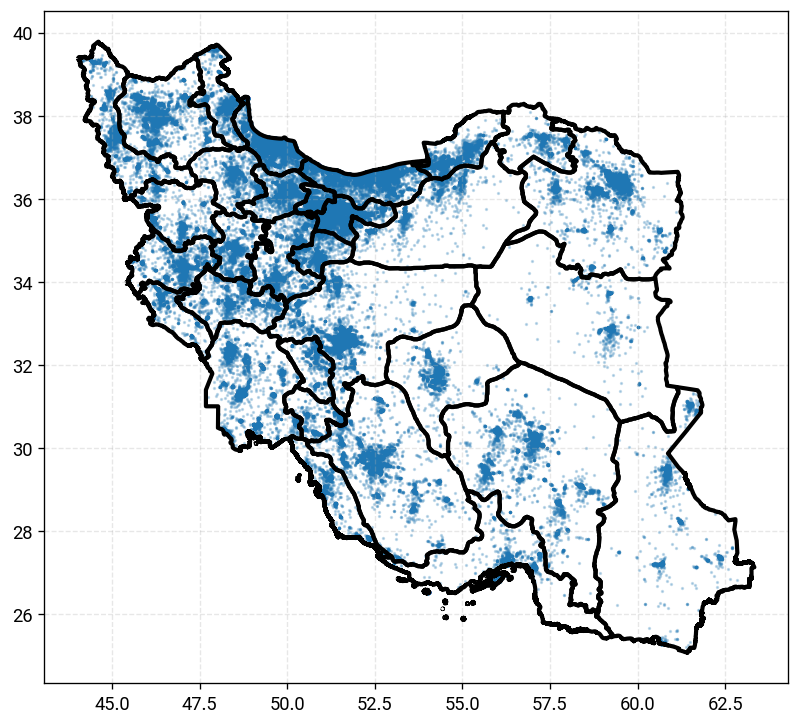

In [117]:
ax = iran.boundary.plot(figsize=(8, 8), color="black")

inside.plot(ax=ax, markersize=1, alpha=0.25)

plt.show()

In [118]:
df.shape

(998241, 60)

### Feature Engineering

In [119]:
fe_df = df.copy()

In [120]:
fe_df["building_age"] = 1404 - fe_df["construction_year"]

In [121]:
amenity_cols = [
    "has_parking",
    "has_warehouse",
    "has_elevator",
    "has_balcony",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
    "has_barbecue",
]

fe_df["amenity_count"] = fe_df[amenity_cols].eq(True).sum(axis=1)

In [122]:
fe_df["is_top_floor"] = fe_df["floor"] == fe_df["total_floors_count"]

In [123]:
fe_df["is_ground_floor"] = fe_df["floor"] == 0

In [124]:
fe_df["floor_ratio"] = fe_df["floor"] / fe_df["total_floors_count"]

In [125]:
fe_df["full_deposit"] = fe_df["credit_value"] + fe_df["rent_value"] * (
    100_000_000 / 3_000_000
)

In [126]:
fe_df["is_new_building"] = fe_df["building_age"] <= 5

In [127]:
fe_df["is_old_building"] = fe_df["building_age"] >= 20

In [128]:
fe_df["rooms_per_100sqm"] = fe_df["rooms_count"] * 100 / fe_df["building_size"]

In [129]:
fe_df["units_in_building"] = fe_df["unit_per_floor"] * fe_df["total_floors_count"]

In [152]:
fe_df["created_year"] = fe_df["created_at_month"].dt.year
fe_df["created_month"] = fe_df["created_at_month"].dt.month
fe_df.drop(columns="created_at_month", inplace=True)

In [153]:
df = fe_df

### Machine Learning

In [227]:
sale_df = df[df["cat2_slug"] == "residential-sell"].copy()

In [228]:
rent_df = df[df["cat2_slug"] == "residential-rent"].copy()

In [229]:
print(sale_df.shape)
print(rent_df.shape)

(557817, 71)
(276081, 71)


In [230]:
sale_df["price_value"].describe()

count    5.322260e+05
mean     9.066419e+09
std      1.128404e+11
min      1.000000e+00
25%      1.420000e+09
50%      2.800000e+09
75%      5.775000e+09
max      9.900000e+12
Name: price_value, dtype: float64

In [231]:
rent_df["full_deposit"].describe()

count    2.747160e+05
mean     2.466304e+10
std      4.114909e+12
min      1.110000e+02
25%      2.833333e+08
50%      4.666667e+08
75%      8.666666e+08
max      1.851867e+15
Name: full_deposit, dtype: float64

In [232]:
sale_df["price_value"].isna().sum()

np.int64(25591)

In [233]:
rent_df["full_deposit"].isna().sum()

np.int64(1365)

In [234]:
sale_df = sale_df.dropna(subset=["price_value"])
rent_df = rent_df.dropna(subset=["full_deposit"])

In [235]:
bool_cols = [
    "has_pool",
    "has_sauna",
    "has_jacuzzi",
    "has_barbecue",
    "has_security_guard",
    "has_gas",
    "has_water",
    "has_electricity",
    "has_elevator",
    "has_balcony",
    "has_parking",
    "has_warehouse",
    "is_rebuilt",
]

for dataset in [sale_df, rent_df]:
    dataset[bool_cols] = dataset[bool_cols].fillna(False)
    dataset[bool_cols] = dataset[bool_cols].astype(bool)

In [236]:
drop_cols = [
    # targets
    "price_value",
    "rent_value",
    "credit_value",
    "full_deposit",
    # transformed targets
    "transformable_price",
    "transformable_credit",
    "transformable_rent",
    "transformed_credit",
    "transformed_rent",
    "rent_credit_transform",
    # daily temporary rent
    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",
    "cost_per_extra_person",
    # text
    "title",
    "description",
    "rent_to_single",
]

In [237]:
sale_drop = drop_cols + [
    "rent_mode",
    "rent_type",
    "credit_mode",
    "property_type",
    "has_business_deed",
    "regular_person_capacity",
    "extra_person_capacity",
    "location_radius",
]

In [238]:
X_sale = sale_df.drop(columns=sale_drop)
y_sale = sale_df["price_value"]

In [239]:
rent_drop = drop_cols + [
    "price_mode",
    "property_type",
    "has_business_deed",
    "regular_person_capacity",
    "extra_person_capacity",
    "location_radius",
]

In [240]:
X_rent = rent_df.drop(columns=rent_drop)
y_rent = rent_df["full_deposit"]

In [241]:
from sklearn.model_selection import train_test_split

X_train_sale, X_test_sale, y_train_sale, y_test_sale = train_test_split(
    X_sale,
    y_sale,
    test_size=0.20,
    random_state=42,
)

X_train_sale, X_val_sale, y_train_sale, y_val_sale = train_test_split(
    X_train_sale,
    y_train_sale,
    test_size=0.20,
    random_state=42,
)

In [242]:
X_train_rent, X_test_rent, y_train_rent, y_test_rent = train_test_split(
    X_rent,
    y_rent,
    test_size=0.20,
    random_state=42,
)

X_train_rent, X_val_rent, y_train_rent, y_val_rent = train_test_split(
    X_train_rent,
    y_train_rent,
    test_size=0.20,
    random_state=42,
)

In [243]:
X_train_sale.dtypes.value_counts()

bool        13
Int8         5
float32      4
boolean      4
Int16        2
int32        2
category     1
category     1
category     1
str          1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Int64        1
Float64      1
Float32      1
Name: count, dtype: int64

In [244]:
X_train_rent.dtypes.value_counts()

bool        13
Int8         5
float32      4
boolean      4
category     2
Int16        2
int32        2
category     1
category     1
category     1
str          1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Int64        1
Float64      1
Float32      1
Name: count, dtype: int64

In [245]:
import numpy as np

y_train_sale_log = np.log1p(y_train_sale)
y_val_sale_log = np.log1p(y_val_sale)

In [246]:
y_train_rent_log = np.log1p(y_train_rent)
y_val_rent_log = np.log1p(y_val_rent)

In [247]:
print(X_train_sale.shape)
print(X_val_sale.shape)
print(X_test_sale.shape)

print()

print(X_train_rent.shape)
print(X_val_rent.shape)
print(X_test_rent.shape)

(340624, 46)
(85156, 46)
(106446, 46)

(175817, 48)
(43955, 48)
(54944, 48)


In [248]:
X_train_sale.isna().sum().sort_values(ascending=False).head(30)

user_type                  235956
building_direction         211169
has_cooling_system         208336
has_heating_system         199368
neighborhood_slug          199357
has_warm_water_provider    195480
land_size                  193536
floor_material             184453
has_restroom               183633
deed_type                  179592
location_longitude         117813
location_latitude          117813
city_slug                       1
cat2_slug                       0
has_balcony                     0
unit_per_floor                  0
total_floors_count              0
rooms_count                     0
floor                           0
building_size                   0
cat3_slug                       0
price_mode                      0
has_electricity                 0
has_water                       0
is_rebuilt                      0
construction_year               0
has_gas                         0
has_elevator                    0
has_parking                     0
has_warehouse 

In [249]:
X_train_rent.isna().sum().sort_values(ascending=False).head(30)

deed_type                  175816
land_size                  134741
rent_type                  121602
user_type                  121386
building_direction         100712
has_cooling_system          88310
neighborhood_slug           85924
has_heating_system          83701
has_warm_water_provider     79945
floor_material              74410
has_restroom                73849
location_latitude           58403
location_longitude          58403
cat3_slug                       0
city_slug                       0
cat2_slug                       0
has_balcony                     0
unit_per_floor                  0
total_floors_count              0
rooms_count                     0
floor                           0
building_size                   0
rent_mode                       0
credit_mode                     0
has_electricity                 0
has_water                       0
is_rebuilt                      0
construction_year               0
has_gas                         0
has_elevator  

In [251]:
categorical_features_sale = [
    col
    for col in X_train_sale.columns
    if str(X_train_sale[col].dtype) in ["category", "string", "str"]
]
print(categorical_features_sale)

['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'user_type', 'price_mode', 'deed_type', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material']


In [252]:
categorical_features_rent = [
    col
    for col in X_train_rent.columns
    if str(X_train_rent[col].dtype) in ["category", "string", "str"]
]
print(categorical_features_rent)

['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'user_type', 'rent_mode', 'rent_type', 'credit_mode', 'deed_type', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material']


In [253]:
for col in categorical_features_sale:
    X_train_sale[col] = X_train_sale[col].astype("string").fillna("Unknown")
    X_val_sale[col] = X_val_sale[col].astype("string").fillna("Unknown")
    X_test_sale[col] = X_test_sale[col].astype("string").fillna("Unknown")

for col in categorical_features_rent:
    X_train_rent[col] = X_train_rent[col].astype("string").fillna("Unknown")
    X_val_rent[col] = X_val_rent[col].astype("string").fillna("Unknown")
    X_test_rent[col] = X_test_rent[col].astype("string").fillna("Unknown")

In [254]:
X_train_sale.isna().sum().sort_values(ascending=False).head(20)

land_size             193536
location_longitude    117813
location_latitude     117813
neighborhood_slug          0
city_slug                  0
cat2_slug                  0
price_mode                 0
building_size              0
deed_type                  0
floor                      0
rooms_count                0
total_floors_count         0
user_type                  0
cat3_slug                  0
has_balcony                0
unit_per_floor             0
has_elevator               0
has_warehouse              0
is_rebuilt                 0
has_water                  0
dtype: int64

In [255]:
X_train_rent.isna().sum().sort_values(ascending=False).head(20)

land_size             134741
location_longitude     58403
location_latitude      58403
cat2_slug                  0
user_type                  0
rent_mode                  0
city_slug                  0
cat3_slug                  0
credit_mode                0
building_size              0
deed_type                  0
floor                      0
rooms_count                0
total_floors_count         0
rent_type                  0
neighborhood_slug          0
has_balcony                0
unit_per_floor             0
has_elevator               0
has_warehouse              0
dtype: int64

In [256]:
print(X_train_sale.shape)
print(X_train_sale.dtypes.value_counts())
print(X_train_sale.isna().sum().sum())
print(y_train_sale.isna().sum())

(340624, 46)
string     13
bool       13
Int8        5
float32     4
boolean     4
Int16       2
int32       2
Int64       1
Float64     1
Float32     1
Name: count, dtype: int64
429162
0


In [257]:
print(X_train_rent.shape)
print(X_train_rent.dtypes.value_counts())
print(X_train_rent.isna().sum().sum())
print(y_train_rent.isna().sum())

(175817, 48)
string     15
bool       13
Int8        5
float32     4
boolean     4
Int16       2
int32       2
Int64       1
Float64     1
Float32     1
Name: count, dtype: int64
251547
0


In [262]:
sale_features = [
    "building_size",
    "building_age",
    "rooms_count",
    "floor",
    "total_floors_count",
    "city_slug",
    "neighborhood_slug",
    "cat3_slug",
    "has_elevator",
    "has_parking",
    "amenity_count",
    "created_year",
    "created_month",
]
rent_features = [
    "building_size",
    "building_age",
    "rooms_count",
    "floor",
    "total_floors_count",
    "city_slug",
    "neighborhood_slug",
    "cat3_slug",
    "has_elevator",
    "has_parking",
    "amenity_count",
    "created_year",
    "created_month",
]

In [263]:
X_train_sale_small = X_train_sale[sale_features]
X_val_sale_small   = X_val_sale[sale_features]
X_test_sale_small  = X_test_sale[sale_features]
X_train_rent_small = X_train_rent[rent_features]
X_val_rent_small   = X_val_rent[rent_features]
X_test_rent_small  = X_test_rent[rent_features]

In [264]:
cat_sale = [
    c
    for c in X_train_sale_small.columns
    if str(X_train_sale_small[c].dtype) in ["string", "category", "str"]
]
cat_rent = [
    c
    for c in X_train_rent_small.columns
    if str(X_train_rent_small[c].dtype) in ["string", "category", "str"]
]